In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [2]:
import yfinance as yf

# Download Apple stock data
df = yf.download('AAPL', start='2015-01-01', end='2023-12-31')

df = df[['Close']]
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.192604
2015-01-05,23.511061
2015-01-06,23.513271
2015-01-07,23.842987
2015-01-08,24.759073


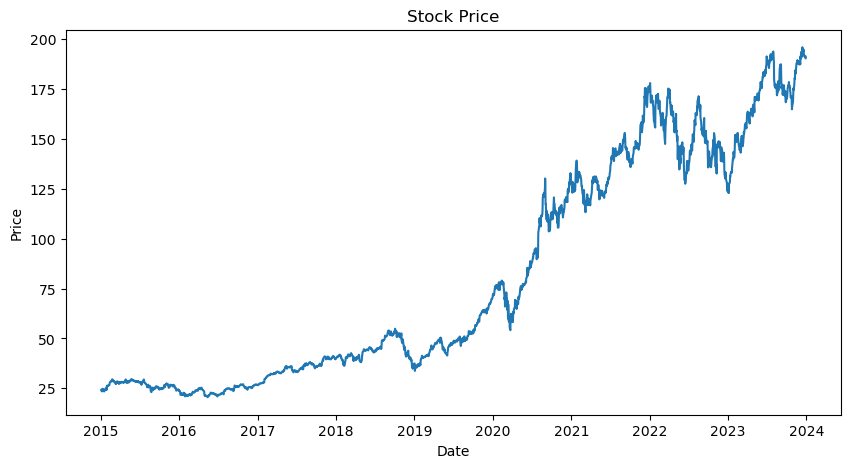

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df.values)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [5]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

# Reshape for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [6]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

e:\Anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0101
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 3.5655e-04
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 3.3875e-04
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.3307e-04
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.2062e-04
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.2198e-04
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 3.0190e-04
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.2557e-04
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.8100e-04
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 2.7427e-04


In [8]:
predicted = model.predict(X_test)

# Inverse scaling
predicted = scaler.inverse_transform(predicted.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


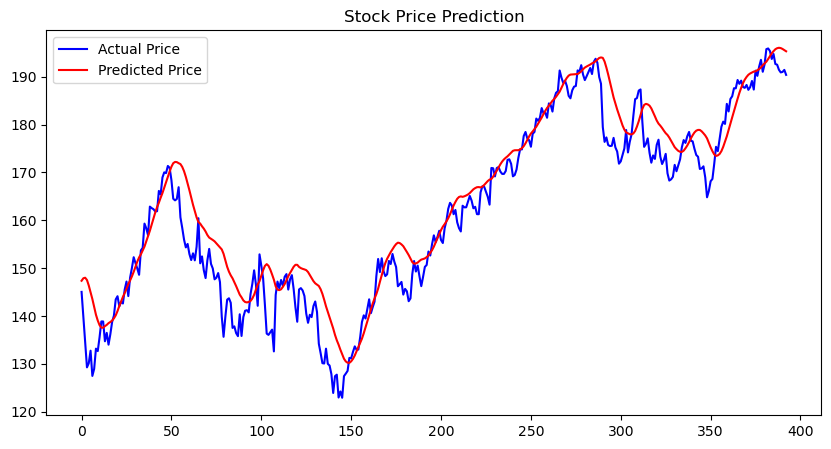

In [9]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, color='blue', label='Actual Price')
plt.plot(predicted, color='red', label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()